IRON Kaggle - Sales Prediction
To solve - Sales Regression 
Evaluation Metric - R2 score, evaluation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Load data

In [2]:
df = pd.read_csv('C:\\Users\\priya\\AIcoursework\\ProjectChallenge\\training.csv')
print('Shape:', df.shape)
df.head()

Shape: (640840, 10)


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


In [4]:
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [5]:
df.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [6]:
print("School holidays:", df["school_holiday"].unique())
print("State Holidays:", df["state_holiday"].unique())
print("Promotion:", df["promotion"].unique())
print("Open:", df["open"].value_counts())  ### drop and check accuracy


School holidays: [0 1]
State Holidays: ['0' 'a' 'c' 'b']
Promotion: [0 1]
Open: open
1    532016
0    108824
Name: count, dtype: int64


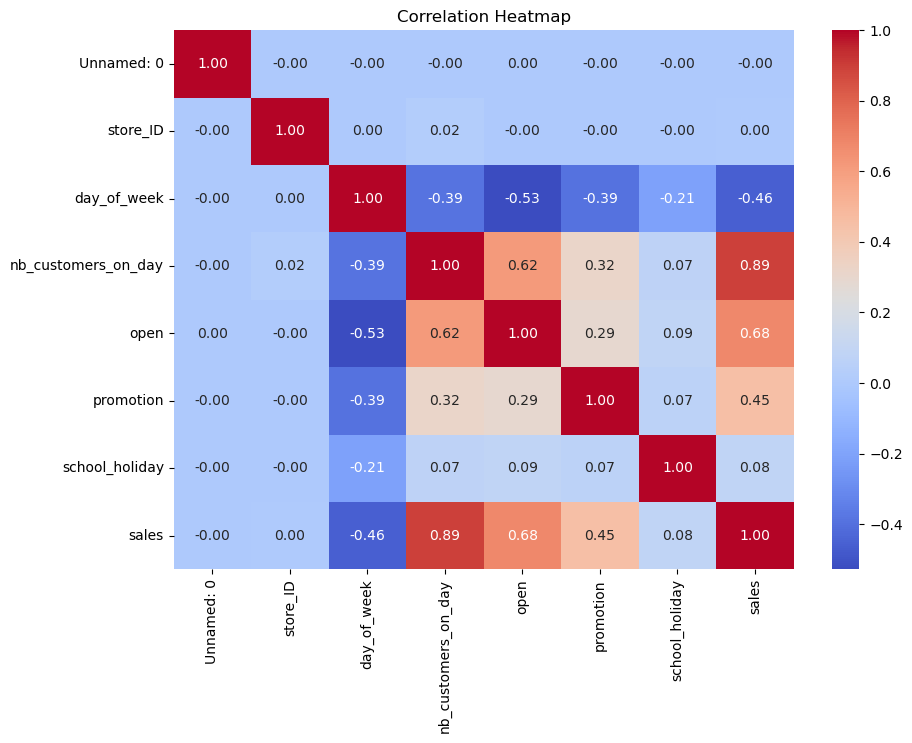

In [7]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Data Cleaning

In [8]:
# Filter: keep only open store days (closed stores have sales=0, not useful for prediction)
df_clean = df[df['open'] == 1].copy()
print(f'Rows before filtering: {len(df)}')
print(f'Rows after filtering (open only): {len(df_clean)}')

# Drop the index column and 'open' (all 1s now)
df_clean.drop(columns=['Unnamed: 0', 'open'], inplace=True)
print('Dropped: Unnamed: 0, open')
df_clean.head()

Rows before filtering: 640840
Rows after filtering (open only): 532016
Dropped: Unnamed: 0, open


,store_ID,day_of_week,date,nb_customers_on_day,promotion,state_holiday,school_holiday,sales
0,366,4,2013-04-18,517,0,0,0,4422
1,394,6,2015-04-11,694,0,0,0,8297
2,807,4,2013-08-29,970,1,0,0,9729
3,802,2,2013-05-28,473,1,0,0,6513
4,726,4,2013-10-10,1068,1,0,0,10882


In [9]:
# Confirm no missing values remain
print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


In [10]:
# Parse date column and extract time features
df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean['month']        = df_clean['date'].dt.month
df_clean['year']         = df_clean['date'].dt.year
df_clean['week']         = df_clean['date'].dt.isocalendar().week.astype(int)
df_clean['day_of_month'] = df_clean['date'].dt.day
df_clean['is_weekend']   = (df_clean['day_of_week'] >= 6).astype(int)

print('New date features added: month, year, week, day_of_month, is_weekend')
df_clean[['date','month','year','week','day_of_month','is_weekend']].head()

New date features added: month, year, week, day_of_month, is_weekend


,date,month,year,week,day_of_month,is_weekend
0,2013-04-18,4,2013,16,18,0
1,2015-04-11,4,2015,15,11,1
2,2013-08-29,8,2013,35,29,0
3,2013-05-28,5,2013,22,28,0
4,2013-10-10,10,2013,41,10,0


In [11]:
# Encode state_holiday: '0'=no holiday, 'a'=public, 'b'=Easter, 'c'=Christmas
le = LabelEncoder()

df_clean['state_holiday_enc'] = le.fit_transform(df_clean['state_holiday'])

print('state_holiday encoding mapping:')
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {label!r} -> {code}')

state_holiday encoding mapping:
  '0' -> 0
  'a' -> 1
  'b' -> 2
  'c' -> 3


In [12]:
numeric_cols = [
    "nb_customers_on_day",
    "open",
    "promotion",
    "school_holiday",
    "day_of_week"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df[col], errors="coerce")

In [13]:
df_clean = pd.get_dummies(df_clean, drop_first=False)

In [14]:
df_clean.head(5)

,store_ID,day_of_week,date,nb_customers_on_day,promotion,school_holiday,sales,month,year,week,day_of_month,is_weekend,state_holiday_enc,open,state_holiday_0,state_holiday_a,state_holiday_b,state_holiday_c
0,366,4,2013-04-18,517,0,0,4422,4,2013,16,18,0,0,1,True,False,False,False
1,394,6,2015-04-11,694,0,0,8297,4,2015,15,11,1,0,1,True,False,False,False
2,807,4,2013-08-29,970,1,0,9729,8,2013,35,29,0,0,1,True,False,False,False
3,802,2,2013-05-28,473,1,0,6513,5,2013,22,28,0,0,1,True,False,False,False
4,726,4,2013-10-10,1068,1,0,10882,10,2013,41,10,0,0,1,True,False,False,False


In [15]:
# Store-level aggregation features (mean, median, std of sales per store)
# These capture the baseline performance of each store
store_stats = df_clean.groupby('store_ID')['sales'].agg(['mean','median','std'])
store_stats.columns = ['store_mean_sales', 'store_med_sales', 'store_std_sales']
store_stats = store_stats.reset_index()

df_clean = df_clean.merge(store_stats, on='store_ID', how='left')
print('Store-level features added: store_mean_sales, store_med_sales, store_std_sales')
df_clean[['store_ID','store_mean_sales','store_med_sales','store_std_sales']].head()

Store-level features added: store_mean_sales, store_med_sales, store_std_sales


,store_ID,store_mean_sales,store_med_sales,store_std_sales
0,366,6206.869739,6011.0,2217.926336
1,394,8404.937378,8207.0,1997.824459
2,807,9824.892713,9773.5,1678.089636
3,802,6754.329060,6561.0,1652.507819
4,726,11052.675620,10497.5,3809.830786


Split

In [16]:
FEATURES = [
    'store_ID',
    'day_of_week',
    'nb_customers_on_day',
    'promotion',
    'state_holiday_enc',
    'school_holiday',
    'month',
    'year',
    'week',
    'day_of_month',
    'is_weekend',
    'store_mean_sales',
    'store_med_sales',
    'store_std_sales',
]

TARGET = 'sales'


In [17]:
X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape:         {y.shape}')
print(f'Features used: {FEATURES}')

Feature matrix shape: (532016, 14)
Target shape:         (532016,)
Features used: ['store_ID', 'day_of_week', 'nb_customers_on_day', 'promotion', 'state_holiday_enc', 'school_holiday', 'month', 'year', 'week', 'day_of_month', 'is_weekend', 'store_mean_sales', 'store_med_sales', 'store_std_sales']


Train Validation Split 

In [18]:
# Sort by date for a realistic temporal split
df_sorted = df_clean.sort_values('date')
X_sorted  = X.loc[df_sorted.index]
y_sorted  = y.loc[df_sorted.index]

split_idx = int(len(df_sorted) * 0.80)

X_train, X_val = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_val = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

print(f'Training set   : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation set : {X_val.shape[0]:,} rows  ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Train dates    : {df_sorted["date"].iloc[0].date()} → {df_sorted["date"].iloc[split_idx-1].date()}')
print(f'Val dates      : {df_sorted["date"].iloc[split_idx].date()} → {df_sorted["date"].iloc[-1].date()}')

Training set   : 425,612 rows  (80%)
Validation set : 106,404 rows  (20%)
Train dates    : 2013-01-01 → 2015-01-30
Val dates      : 2015-01-30 → 2015-07-31


Ridge Regression - Baseline model

In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

ridge_train_r2 = r2_score(y_train, ridge.predict(X_train_sc))
ridge_val_r2   = r2_score(y_val,   ridge.predict(X_val_sc))

print(f'Ridge Regression')
print(f'  Train R²      : {ridge_train_r2:.4f}')
print(f'  Validation R² : {ridge_val_r2:.4f}')
print(f'  Gap           : {ridge_train_r2 - ridge_val_r2:.4f}')

Ridge Regression
  Train R²      : 0.8230
  Validation R² : 0.8221
  Gap           : 0.0009


Random Forest

In [20]:
# Use a sample for faster training during exploration
sample_frac = 0.20  # increase to 1.0 for final training
X_tr_s = X_train.sample(frac=sample_frac, random_state=42)
y_tr_s = y_train.loc[X_tr_s.index]

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr_s, y_tr_s)

rf_train_r2 = r2_score(y_tr_s, rf.predict(X_tr_s))
rf_val_r2   = r2_score(y_val,  rf.predict(X_val))

print(f'Random Forest Regressor')
print(f'  Train R²      : {rf_train_r2:.4f}')
print(f'  Validation R² : {rf_val_r2:.4f}')
print(f'  Gap           : {rf_train_r2 - rf_val_r2:.4f}')

Random Forest Regressor
  Train R²      : 0.9691
  Validation R² : 0.9186
  Gap           : 0.0505


In [ ]:
##xgboost


Gradient Boosting

In [21]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_tr_s, y_tr_s)  # same sample as RF for fair comparison

gb_train_r2 = r2_score(y_tr_s, gb.predict(X_tr_s))
gb_val_r2   = r2_score(y_val,  gb.predict(X_val))

print(f'Gradient Boosting Regressor')
print(f'  Train R²      : {gb_train_r2:.4f}')
print(f'  Validation R² : {gb_val_r2:.4f}')
print(f'  Gap           : {gb_train_r2 - gb_val_r2:.4f}')

Gradient Boosting Regressor
  Train R²      : 0.9448
  Validation R² : 0.9132
  Gap           : 0.0316


In [24]:
# Re-train Gradient Boosting on all training data (not just 20% sample)
final_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
final_model.fit(X_train, y_train)

final_train_r2 = r2_score(y_train, final_model.predict(X_train))
final_val_r2   = r2_score(y_val,   final_model.predict(X_val))

print('=== FINAL MODEL RESULTS ===')
print(f'  Model         : Gradient Boosting Regressor')
print(f'  Train R²      : {final_train_r2:.4f}  ({final_train_r2*100:.2f}%)')
print(f'  Validation R² : {final_val_r2:.4f}  ({final_val_r2*100:.2f}%)')
print(f'  Gap           : {final_train_r2 - final_val_r2:.4f}')
print(f'  R² Prediction (our estimate for real data): ~{final_val_r2*100:.0f}%')

=== FINAL MODEL RESULTS ===
  Model         : Gradient Boosting Regressor
  Train R²      : 0.9424  (94.24%)
  Validation R² : 0.9132  (91.32%)
  Gap           : 0.0292
  R² Prediction (our estimate for real data): ~91%


In [25]:
def preprocess_real(raw_df, store_stats_df, le):
    """
    Preprocess REAL_DATA.csv using the same pipeline as training.
    store_stats_df : store_stats computed from training data.
    le             : fitted LabelEncoder for state_holiday.
    """
    df = raw_df.copy()

    # Filter open stores
    df = df[df['open'] == 1].copy()

    # Drop unnecessary columns (index column is called 'index' in REAL_DATA)
    for col in ['index', 'Unnamed: 0', 'open']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Date features
    df['date']         = pd.to_datetime(df['date'])
    df['month']        = df['date'].dt.month
    df['year']         = df['date'].dt.year
    df['week']         = df['date'].dt.isocalendar().week.astype(int)
    df['day_of_month'] = df['date'].dt.day
    df['is_weekend']   = (df['day_of_week'] >= 6).astype(int)

    # Store-level features from training data
    df = df.merge(store_stats_df, on='store_ID', how='left')

    # Encode state_holiday using the fitted encoder from training
    df['state_holiday_enc'] = le.transform(df['state_holiday'])

    return df


# Load and preprocess REAL_DATA
real_df        = pd.read_csv('C:\\Users\\priya\\AIcoursework\\ProjectChallenge\\REAL_DATA.csv')
real_processed = preprocess_real(real_df, store_stats, le)

print(f'REAL_DATA rows total         : {len(real_df):,}')
print(f'REAL_DATA rows (open stores) : {len(real_processed):,}')
print(f'Missing values after preprocessing:')
print(real_processed[FEATURES].isnull().sum())

REAL_DATA rows total         : 71,205
REAL_DATA rows (open stores) : 59,105
Missing values after preprocessing:
store_ID               0
day_of_week            0
nb_customers_on_day    0
promotion              0
state_holiday_enc      0
school_holiday         0
month                  0
year                   0
week                   0
day_of_month           0
is_weekend             0
store_mean_sales       0
store_med_sales        0
store_std_sales        0
dtype: int64


C:\Users\priya\AppData\Local\Temp\ipykernel_32148\2095712591.py:18: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date']         = pd.to_datetime(df['date'])


In [26]:
# Generate predictions
predictions = final_model.predict(real_processed[FEATURES])

# Build output dataframe
output = real_processed[['store_ID', 'date']].copy()
output['predicted_sales'] = predictions.astype(int)

# Save to G1.csv
output.to_csv('G1.csv', index=False)

print(f'Predictions saved to G1.csv')
print(f'Total predictions : {len(output):,}')
print(f'Predicted sales — min: {output["predicted_sales"].min():,}  max: {output["predicted_sales"].max():,}  mean: {output["predicted_sales"].mean():,.0f}')
output.head(10)

Predictions saved to G1.csv
Total predictions : 59,105
Predicted sales — min: -382  max: 33,737  mean: 6,903


,store_ID,date,predicted_sales
0,404,2014-03-19,5368
1,683,2013-01-29,7446
2,920,2014-03-19,5828
3,758,2014-06-26,4348
4,563,2015-02-16,4601
5,930,2014-11-22,8321
6,49,2015-01-13,7854
7,787,2015-07-23,8291
8,782,2013-09-19,4164
9,933,2013-12-09,7812
